<a href="https://colab.research.google.com/github/SutthipongS/SP500-Hybrid-GARCH-LSTM-DCA/blob/main/IS_Step_1to7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การพัฒนากลยุทธ์การลงทุนแบบกำหนดเป้าหมายความเสี่ยง (Volatility Targeting) ด้วย Hybrid Deep Learning

## Step 1: Data Acquisition & Preprocessing (การดึงและเตรียมข้อมูล)
ในขั้นตอนนี้จะเป็นการดึงข้อมูลอนุกรมเวลารายวัน ตั้งแต่ปี ค.ศ. 2016 ถึง 2025 ประกอบด้วย ดัชนี S&P 500, ดัชนีความผันผวน VIX และดัชนี Euro Stoxx 50 โดยใช้ราคาเปิด (Open Price) จากนั้นจะทำการทำความสะอาดข้อมูล จัดการข้อมูลที่เวลาไม่ตรงกัน (Time Zone Alignment) และแปลงข้อมูลราคาให้เป็นผลตอบแทนแบบลอการิทึม (Log Returns) เพื่อให้ข้อมูลมีความนิ่ง (Stationary)

In [1]:
pip install yfinance arch tensorflow vectorbt

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import random
import tensorflow as tf

# ฟังก์ชันล็อกค่าความสุ่มให้อยู่กับที่ (Reproducibility)
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"🔒 ล็อกความสุ่มด้วย Seed {seed} เรียบร้อยแล้ว ผลลัพธ์จะเท่าเดิมทุกรอบ!")

# เรียกใช้งานฟังก์ชัน
set_seeds(42)

# 1. กำหนดช่วงเวลาและสัญลักษณ์ของสินทรัพย์ (2016-2025)
start_date = '2016-01-01'
end_date = '2025-12-31'

tickers = {
    'SP500': '^GSPC',
    'VIX': '^VIX',
    'EuroStoxx50': '^STOXX50E'
}

# 2. ดึงข้อมูลและเลือกใช้คอลัมน์ที่เหมาะสม
df_raw = pd.DataFrame()
for name, ticker in tickers.items():
    # ดึงข้อมูลทีละตัว
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)

    # ใช้ ราคาเปิด (Open Price) สำหรับ Euro Stoxx 50 ตามที่ระบุในขอบเขตการศึกษา
    if name == 'EuroStoxx50':
        # ใช้ .squeeze() เพื่อป้องกันปัญหา MultiIndex จาก yfinance เวอร์ชันใหม่
        df_raw[name] = data['Open'].squeeze()
    else:
        # เปลี่ยนจาก 'Adj Close' เป็น 'Close' เพราะดัชนีไม่มีการจ่ายปันผล
        df_raw[name] = data['Close'].squeeze()

# 3. จัดการข้อมูลที่เวลาไม่ตรงกัน (Time Zone Alignment) โดยตัดวันหยุดที่ตลาดใดตลาดหนึ่งปิดออก
df_aligned = df_raw.dropna()

# 4. แปลงข้อมูล (Data Transformation)
df_processed = pd.DataFrame(index=df_aligned.index)

# - คำนวณ Log Returns สำหรับดัชนีหุ้น
df_processed['SP500_Return'] = np.log(df_aligned['SP500'] / df_aligned['SP500'].shift(1))
df_processed['EuroStoxx50_Return'] = np.log(df_aligned['EuroStoxx50'] / df_aligned['EuroStoxx50'].shift(1))

# - คำนวณ Daily Change สำหรับ VIX (เนื่องจากเป็นค่าความผันผวนอยู่แล้ว)
df_processed['VIX_Change'] = df_aligned['VIX'] - df_aligned['VIX'].shift(1)

# ลบแถวแรกที่เป็น NaN จากการคำนวณ Shift
df_processed = df_processed.dropna()

print("ขนาดของชุดข้อมูลที่พร้อมใช้งาน:", df_processed.shape)
display(df_processed.head())

🔒 ล็อกความสุ่มด้วย Seed 42 เรียบร้อยแล้ว ผลลัพธ์จะเท่าเดิมทุกรอบ!
ขนาดของชุดข้อมูลที่พร้อมใช้งาน: (2447, 3)


,SP500_Return,EuroStoxx50_Return,VIX_Change
Date,,,
2016-01-05,0.002010,-0.028844,-1.360001
2016-01-06,-0.013202,-0.000791,1.250000
2016-01-07,-0.023986,-0.012753,4.400000
2016-01-08,-0.010898,-0.013844,2.020000
2016-01-11,0.000853,-0.018671,-2.710001


## Step 2: Exploratory Data Analysis (EDA) (การสำรวจข้อมูล)
การทำความเข้าใจพฤติกรรมของข้อมูลเป็นสิ่งสำคัญ โดยเฉพาะทฤษฎีการจัดกลุ่มความผันผวน (Volatility Clustering) ซึ่งเป็นพื้นฐานสำคัญของการพยากรณ์ความผันผวน การสำรวจนี้จะตรวจสอบ:
1. ลักษณะการกระจายตัว (Distribution) และปรากฏการณ์หางหนา (Fat Tails)
2. การแกว่งตัวของผลตอบแทนรายวันและพฤติกรรมความผันผวนแบบกระจุกตัว

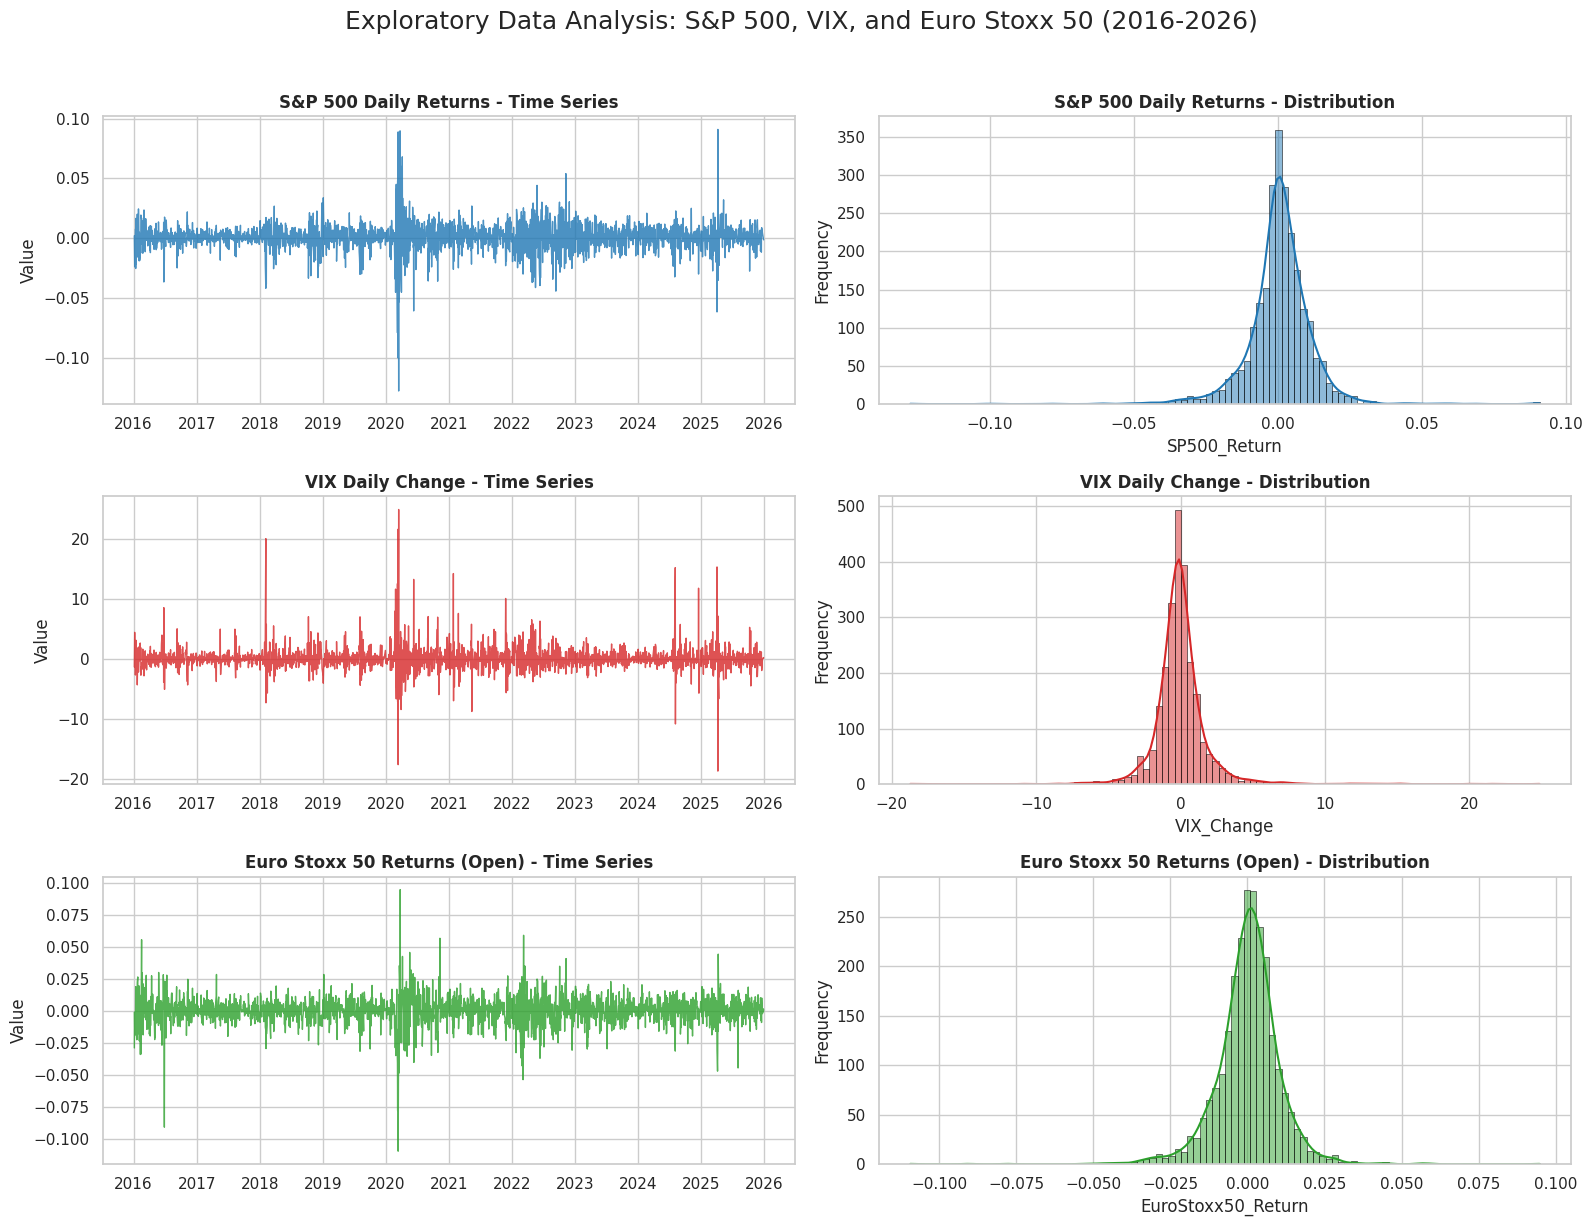


--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
SP500_Return,2447.0,0.000503,0.011526,-0.127652,-0.003711,0.000769,0.005789,0.090895
EuroStoxx50_Return,2447.0,0.000231,0.010708,-0.109440,-0.004572,0.000702,0.005678,0.094809
VIX_Change,2447.0,-0.002603,1.984741,-18.710003,-0.769999,-0.110000,0.570000,24.860001


In [3]:
# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis: S&P 500, VIX, and Euro Stoxx 50 (2016-2026)', fontsize=18, y=1.02)

# กำหนดตัวแปรและสีสำหรับพล็อต
features = ['SP500_Return', 'VIX_Change', 'EuroStoxx50_Return']
titles = ['S&P 500 Daily Returns', 'VIX Daily Change', 'Euro Stoxx 50 Returns (Open)']
colors = ['#1f77b4', '#d62728', '#2ca02c']

for i in range(3):
    # พล็อต Time Series ด้านซ้าย (ตรวจสอบ Volatility Clustering)
    axes[i, 0].plot(df_processed.index, df_processed[features[i]], color=colors[i], alpha=0.8, linewidth=1)
    axes[i, 0].set_title(titles[i] + ' - Time Series', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Value')

    # พล็อต Histogram และ KDE ด้านขวา (ตรวจสอบ Distribution และ Fat Tails)
    sns.histplot(df_processed[features[i]], bins=100, kde=True, ax=axes[i, 1], color=colors[i], edgecolor='black')
    axes[i, 1].set_title(titles[i] + ' - Distribution', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# แสดงค่าสถิติเชิงพรรณนา (Descriptive Statistics) เพื่อตรวจสอบความเบ้ (Skewness) และความโด่ง (Kurtosis)
print("\n--- Descriptive Statistics ---")
display(df_processed.describe().T)

## Step 3: Correlation Analysis & Feature Selection (การวิเคราะห์ความสัมพันธ์)
หลังจากจัดการข้อมูลให้อยู่ในรูปแบบที่นิ่ง (Stationary) แล้ว ขั้นตอนนี้จะเป็นการยืนยันทฤษฎีด้วยค่าสถิติ โดยการสร้าง Correlation Matrix เพื่อดูความสัมพันธ์ระหว่างผลตอบแทนของ S&P 500, การเปลี่ยนแปลงของ VIX และผลตอบแทนของ Euro Stoxx 50

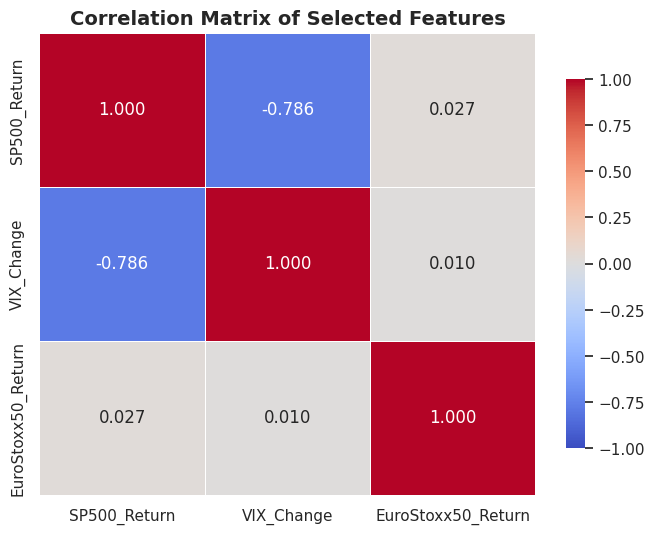


--- Correlation Results ---
S&P 500 vs VIX: -0.786
S&P 500 vs Euro Stoxx 50: 0.027


In [4]:
# 1. คำนวณ Correlation Matrix
correlation_matrix = df_processed[['SP500_Return', 'VIX_Change', 'EuroStoxx50_Return']].corr()

# 2. พล็อต Heatmap เพื่อให้เห็นภาพความสัมพันธ์ชัดเจนขึ้น
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Selected Features', fontsize=14, fontweight='bold')
plt.show()

# สรุปผลความสัมพันธ์
print("\n--- Correlation Results ---")
print(f"S&P 500 vs VIX: {correlation_matrix.loc['SP500_Return', 'VIX_Change']:.3f}")
print(f"S&P 500 vs Euro Stoxx 50: {correlation_matrix.loc['SP500_Return', 'EuroStoxx50_Return']:.3f}")

## Step 4: GARCH Volatility Modeling (แบบจำลอง GARCH)
ขั้นตอนรอยต่อที่สำคัญก่อนที่จะไปถึงโครงข่ายประสาทเทียม คือการสร้างแบบจำลอง GARCH เพื่อจับรูปแบบความผันผวนเชิงเส้น ของผลตอบแทน S&P 500 โดยเราจะทำการสกัดค่าความผันผวนแบบมีเงื่อนไข (Conditional Volatility) ที่พยากรณ์ได้ ออกมาใช้เป็นตัวแปร (Feature) ที่ 4 สำหรับป้อนเข้าสู่โมเดล LSTM ในเฟสถัดไป

                     Constant Mean - GARCH Model Results                      
Dep. Variable:           SP500_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3171.34
Distribution:                  Normal   AIC:                           6350.67
Method:            Maximum Likelihood   BIC:                           6373.88
                                        No. Observations:                 2447
Date:                Wed, Jun 10 2026   Df Residuals:                     2446
Time:                        08:37:05   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0848  1.519e-02      5.581  2.386e-08 [5.502e-0

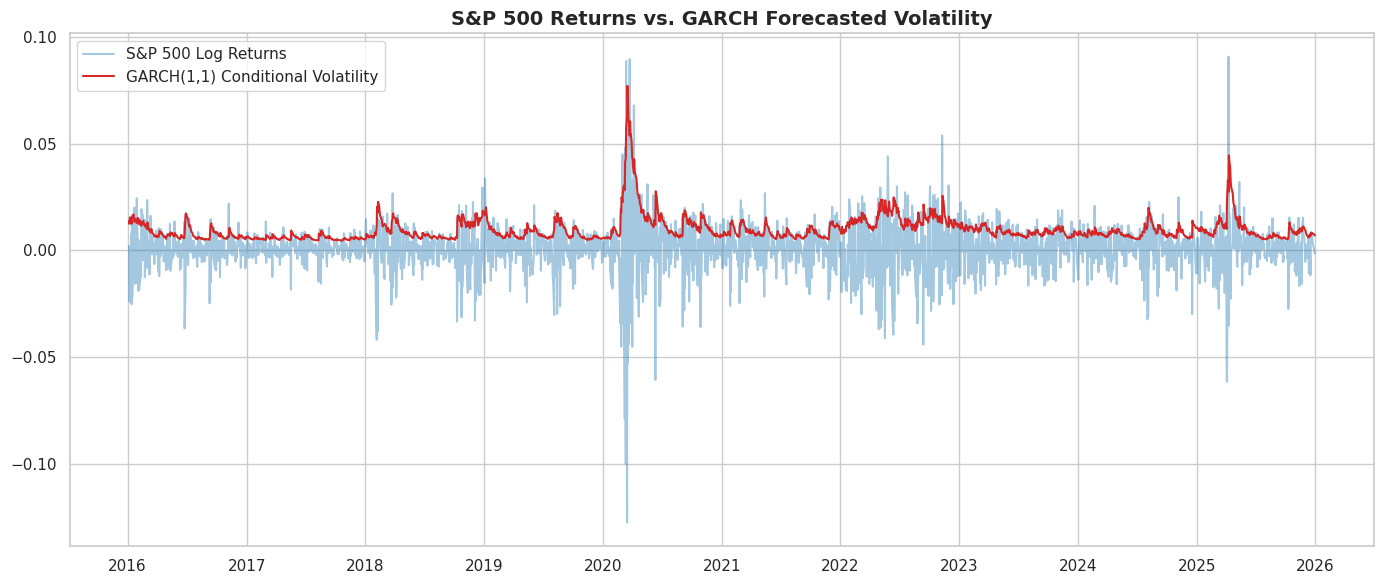


ชุดข้อมูลพร้อมสำหรับนำเข้า LSTM (4 Features):


,SP500_Return,VIX_Change,EuroStoxx50_Return,GARCH_Vol
Date,,,,
2016-01-05,0.002010,-1.360001,-0.028844,0.013751
2016-01-06,-0.013202,1.250000,-0.000791,0.012464
2016-01-07,-0.023986,4.400000,-0.012753,0.012720
2016-01-08,-0.010898,2.020000,-0.013844,0.015445
2016-01-11,0.000853,-2.710001,-0.018671,0.014774


In [5]:
!pip install arch -q
from arch import arch_model

# 1. ปรับสเกลข้อมูล (Scaling)
# GARCH มักจะมีปัญหาในการ Optimize หากตัวเลขผลตอบแทนเล็กเกินไป จึงควรคูณ 100
sp500_returns_scaled = df_processed['SP500_Return'] * 100

# 2. สร้างและฝึกสอนแบบจำลอง GARCH(1,1)
# สมมติฐานค่าเฉลี่ยเป็น Constant และให้ผลตอบแทนมีการกระจายตัวแบบ Normal
garch_model = arch_model(sp500_returns_scaled, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
garch_fitted = garch_model.fit(disp='off')

# พิมพ์สรุปผลลัพธ์ของโมเดล
print(garch_fitted.summary())

# 3. สกัดค่า Conditional Volatility
# หารด้วย 100 กลับ เพื่อให้สเกลกลับไปเท่าเดิมพร้อมใช้ร่วมกับตัวแปรอื่นๆ
df_processed['GARCH_Vol'] = garch_fitted.conditional_volatility / 100

# 4. พล็อตเปรียบเทียบผลตอบแทน S&P 500 กับความผันผวนที่พยากรณ์จาก GARCH
plt.figure(figsize=(14, 6))
plt.plot(df_processed.index, df_processed['SP500_Return'], label='S&P 500 Log Returns', alpha=0.4, color='#1f77b4')
plt.plot(df_processed.index, df_processed['GARCH_Vol'], label='GARCH(1,1) Conditional Volatility', color='#d62728', linewidth=1.5)
plt.title('S&P 500 Returns vs. GARCH Forecasted Volatility', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# ตรวจสอบชุดข้อมูล 4 ตัวแปรที่พร้อมนำไปใช้ใน Phase 2 (LSTM)
print("\nชุดข้อมูลพร้อมสำหรับนำเข้า LSTM (4 Features):")
display(df_processed[['SP500_Return', 'VIX_Change', 'EuroStoxx50_Return', 'GARCH_Vol']].head())

## Step 5: Hybrid Deep Learning (LSTM) (การผสมผสานและฝึกสอน AI)
ขั้นตอนนี้คือการนำข้อมูลทั้ง 4 ตัวแปร (S&P 500 Returns, VIX Change, Euro Stoxx 50 Returns และ GARCH Volatility) มาใช้เป็น Features (X) เพื่อพยากรณ์ความผันผวนในอนาคต (Y)
โดยเราจะทำตามขั้นตอนดังนี้:
1. **Data Scaling:** ปรับสเกลข้อมูลให้อยู่ในช่วง 0-1 (MinMaxScaler) เพื่อให้ Neural Network เรียนรู้ได้ดีขึ้น
2. **Sequence Creation:** จัดกลุ่มข้อมูลย้อนหลัง (Lookback Period) เช่น ดูข้อมูลอดีต 21 วัน (ประมาณ 1 เดือนทำการ) เพื่อทายผลวันพรุ่งนี้
3. **Train/Test Split:** แบ่งข้อมูลสำหรับฝึกสอนและทดสอบ
4. **Model Training:** สร้างและฝึกสอนโครงข่าย LSTM

ขนาด X_train: (1940, 21, 4), Y_train: (1940, 1)
ขนาด X_test: (485, 21, 4), Y_test: (485, 1)

กำลังฝึกสอนโมเดล LSTM... (อาจใช้เวลาสักครู่)
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - loss: 0.0093 - val_loss: 0.0033
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0062 - val_loss: 0.0013
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0024 - val_loss: 3.2798e-04
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0022 - val_loss: 0.0041
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0043 - val_loss: 0.0012
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019 - val_loss: 5.8399e-04
Epoch 9/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016 - val_loss: 9.0606e-04
Epoch 10/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 4.134

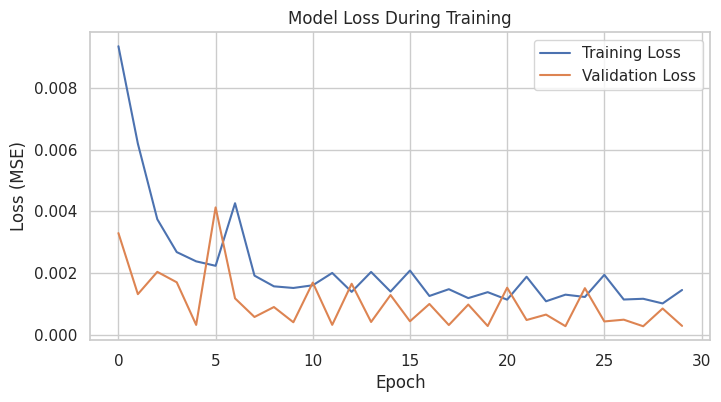

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

ประสิทธิภาพของโมเดล LSTM:
RMSE: 0.002182
MAE: 0.001271


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# 1. เตรียมข้อมูล Features (X) และ Target (Y)
# สมมติฐาน: เราต้องการพยากรณ์ GARCH Volatility ของวันพรุ่งนี้ (t+1)
df_lstm = df_processed[['SP500_Return', 'VIX_Change', 'EuroStoxx50_Return', 'GARCH_Vol']].copy()
df_lstm['Target_Vol'] = df_lstm['GARCH_Vol'].shift(-1) # เลื่อนข้อมูลขึ้น 1 วันเพื่อเป็นเฉลย
df_lstm = df_lstm.dropna()

# 2. ปรับสเกลข้อมูล (Scaling)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

scaled_X = scaler_X.fit_transform(df_lstm[['SP500_Return', 'VIX_Change', 'EuroStoxx50_Return', 'GARCH_Vol']])
scaled_Y = scaler_Y.fit_transform(df_lstm[['Target_Vol']])

# 3. ฟังก์ชันสำหรับสร้าง Sequence (Lookback Period)
def create_sequences(X, Y, lookback):
    Xs, Ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:(i + lookback)])
        Ys.append(Y[i + lookback])
    return np.array(Xs), np.array(Ys)

lookback_days = 21 # ใช้ข้อมูลย้อนหลัง 21 วัน
X_seq, Y_seq = create_sequences(scaled_X, scaled_Y, lookback_days)

# 4. แบ่งข้อมูล Train และ Test (ใช้ 80% แรกเทรน 20% หลังทดสอบ)
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
Y_train, Y_test = Y_seq[:train_size], Y_seq[train_size:]

print(f"ขนาด X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"ขนาด X_test: {X_test.shape}, Y_test: {Y_test.shape}")

# 5. สร้างสถาปัตยกรรม Hybrid LSTM Model
model = Sequential()
# Layer 1: LSTM รับ Input รูปแบบ (Lookback, จำนวน Features)
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # ป้องกัน Overfitting
# Layer 2: LSTM ชั้นที่ 2
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
# Layer 3: Output Layer พยากรณ์ค่าความผันผวน 1 ค่า
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 6. ฝึกสอนโมเดล (Training)
print("\nกำลังฝึกสอนโมเดล LSTM... (อาจใช้เวลาสักครู่)")
history = model.fit(X_train, Y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1, shuffle=False)

# 7. พล็อตดูกราฟ Loss เพื่อเช็คการเรียนรู้
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# 8. วัดความแม่นยำด้วย RMSE และ MAE
predictions_scaled = model.predict(X_test)
predictions = scaler_Y.inverse_transform(predictions_scaled) # แปลงสเกลกลับเป็นค่าจริง
Y_test_actual = scaler_Y.inverse_transform(Y_test)

rmse = math.sqrt(mean_squared_error(Y_test_actual, predictions))
mae = mean_absolute_error(Y_test_actual, predictions)
print(f"\nประสิทธิภาพของโมเดล LSTM:")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")

เปรียบเทียบ LSTM เดียวๆ กับ GARCH+ LSTM

In [7]:
# =========================================================================
# โค้ดส่วนเพิ่ม: สร้าง Baseline Model (LSTM เดี่ยวๆ ไม่ใช้ GARCH)
# เพื่อทำ Ablation Study พิสูจน์ให้กรรมการเห็นความแตกต่าง
# =========================================================================
print("🚀 เริ่มสร้าง Baseline Model (LSTM 3 Features: ไม่ใช้ GARCH)...")

# 1. เลือกเฉพาะ 3 ตัวแปร (ตัด GARCH_Vol ทิ้งไป)
features_base = ['SP500_Return', 'VIX_Change', 'EuroStoxx50_Return']

# 2. ปรับสเกลข้อมูลเฉพาะ 3 ตัวแปรนี้
scaler_X_base = MinMaxScaler(feature_range=(0, 1))
scaled_X_base = scaler_X_base.fit_transform(df_lstm[features_base])

# 3. สร้าง Sequence (ใช้ฟังก์ชัน create_sequences ของคุณได้เลย)
X_seq_base, _ = create_sequences(scaled_X_base, scaled_Y, lookback_days)
# หมายเหตุ: เราไม่จำเป็นต้องรับค่า Y_seq จากฟังก์ชันนี้แล้ว เพราะค่า Y (เฉลย)
# มันเหมือนกับ Y_seq ตัวเดิมของคุณเป๊ะๆ เราจึงใช้ Y_seq, Y_train ของเดิมได้เลย

# 4. แบ่งข้อมูล Train และ Test (ใช้ train_size เดิมของคุณ)
X_train_base = X_seq_base[:train_size]
X_test_base = X_seq_base[train_size:]

print(f"✅ มิติของ X_train_base: {X_train_base.shape} (สังเกตว่า Features จาก 4 จะเหลือแค่ 3)")

# 5. สร้างสถาปัตยกรรม Baseline LSTM Model (โครงสร้างเหมือนกันเป๊ะ เพื่อความแฟร์)
model_base = Sequential()
model_base.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_base.shape[1], X_train_base.shape[2])))
model_base.add(Dropout(0.2))
model_base.add(LSTM(units=50, return_sequences=False))
model_base.add(Dropout(0.2))
model_base.add(Dense(units=1))

model_base.compile(optimizer='adam', loss='mean_squared_error')

# 6. ฝึกสอนโมเดล Baseline
print("\n⏳ กำลังฝึกสอนโมเดล Baseline (LSTM Only)... (รอสักครู่)")
history_base = model_base.fit(X_train_base, Y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0, shuffle=False)
print("✅ เทรนเสร็จสิ้น!")

# 7. วัดผลความแม่นยำบน Test Set
base_predictions_scaled = model_base.predict(X_test_base)
base_predictions_test = scaler_Y.inverse_transform(base_predictions_scaled)

rmse_base = math.sqrt(mean_squared_error(Y_test_actual, base_predictions_test))
mae_base = mean_absolute_error(Y_test_actual, base_predictions_test)

# --- แสดงผลเปรียบเทียบความแม่นยำ ---
print("\n" + "="*50)
print("📊 สรุปเปรียบเทียบประสิทธิภาพบน Test Set (Forecasting Performance)")
print("="*50)
print(f"🟢 Hybrid (GARCH+LSTM) -> RMSE: {rmse:.6f} | MAE: {mae:.6f}")
print(f"🟠 Baseline (LSTM Only)  -> RMSE: {rmse_base:.6f} | MAE: {mae_base:.6f}")
print("="*50)

# =========================================================================
# เตรียมข้อมูลสำหรับส่งไปทำ Backtest จำลองพอร์ตใน Step 6
# =========================================================================
# พยากรณ์ข้อมูลตั้งแต่ต้นจนจบ 10 ปีรวด (Full Predictions)
full_predictions_scaled = model.predict(X_seq) # ของ Hybrid
full_predictions = scaler_Y.inverse_transform(full_predictions_scaled)

base_full_predictions_scaled = model_base.predict(X_seq_base) # ของ Baseline
base_predictions = scaler_Y.inverse_transform(base_full_predictions_scaled)

print("\n📦 เตรียมตัวแปร full_predictions และ base_predictions สำหรับ Step 6 เรียบร้อยแล้ว!")

🚀 เริ่มสร้าง Baseline Model (LSTM 3 Features: ไม่ใช้ GARCH)...
✅ มิติของ X_train_base: (1940, 21, 3) (สังเกตว่า Features จาก 4 จะเหลือแค่ 3)

⏳ กำลังฝึกสอนโมเดล Baseline (LSTM Only)... (รอสักครู่)
✅ เทรนเสร็จสิ้น!
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

📊 สรุปเปรียบเทียบประสิทธิภาพบน Test Set (Forecasting Performance)
🟢 Hybrid (GARCH+LSTM) -> RMSE: 0.002182 | MAE: 0.001271
🟠 Baseline (LSTM Only)  -> RMSE: 0.004909 | MAE: 0.003506
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📦 เตรียมตัวแปร full_predictions และ base_predictions สำหรับ Step 6 เรียบร้อยแล้ว!


## Step 6: Volatility Targeting Strategy & Backtesting (การสร้างกลยุทธ์และจำลองการลงทุน)
ในขั้นตอนนี้ เราจะนำค่าความผันผวนที่ AI พยากรณ์ได้ มาสร้างกลยุทธ์ "เข็มขัดนิรภัย" (Volatility Targeting) โดยการปรับสัดส่วนการลงทุน (Weight) รายวันตามระดับความเสี่ยงที่รับได้:
- หาก AI มองว่าพรุ่งนี้ตลาดผันผวนสูงกว่าเป้าหมาย (High Volatility) -> ลดพอร์ตลง
- หากตลาดผันผวนต่ำ (Low Volatility) -> เพิ่มพอร์ต (สูงสุดไม่เกิน 100%)
- พร้อมคำนวณหักต้นทุนค่าธรรมเนียมขาออก (Exit Fee) 0.107% ของกองทุน E-Class จริง เพื่อประเมิน Net Return

In [8]:
# =========================================================================
# Step 6: AI Smart DCA & Volatility Targeting (Ablation Study)
# ประเมิน 4 กลยุทธ์: Naive, GARCH Only, LSTM Only, Hybrid GARCH+LSTM
# (มีระบบ 3 ตะกร้า: สับเปลี่ยนเข้า MMF + Exit Fee 0.107% + Cooldown T+3)
# =========================================================================
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. รวบรวมค่าพยากรณ์ความผันผวนจากทั้ง 3 โมเดล
# ---------------------------------------------------------
# สมมติว่า full_predictions (Hybrid) และ base_predictions (LSTM only) รันเสร็จแล้วจาก Step 5
seq_length = 21
full_dates = df_lstm.index[seq_length:]

backtest_df = pd.DataFrame(index=full_dates)
backtest_df['Actual_Return'] = df_lstm.loc[full_dates, 'SP500_Return']

# 1.1 ค่าพยากรณ์ Hybrid (4 ตัวแปร)
backtest_df['Hybrid_Forecast_Vol'] = full_predictions.flatten() * np.sqrt(252)

# 1.2 ค่าพยากรณ์ LSTM Only (3 ตัวแปร)
# (ถ้าตัวแปรของคุณไม่ได้ชื่อ base_predictions ให้เปลี่ยนชื่อให้ตรงกันนะครับ)
backtest_df['Base_Forecast_Vol'] = base_predictions.flatten() * np.sqrt(252)

# 1.3 ค่าพยากรณ์ GARCH Only
# ดึงจากคอลัมน์ GARCH_Vol ใน df_lstm ของคุณได้เลย (คูณ sqrt(252) เพื่อทำเป็นรายปี)
backtest_df['GARCH_Forecast_Vol'] = df_lstm.loc[full_dates, 'GARCH_Vol'].values * np.sqrt(252)

# ---------------------------------------------------------
# 2. คำนวณน้ำหนักการลงทุน (Target Weight) ของทั้ง 3 โมเดล
# ---------------------------------------------------------
target_vol = 0.15 # เป้าหมายความผันผวนที่ 15%

backtest_df['W_Hybrid'] = (target_vol / backtest_df['Hybrid_Forecast_Vol']).clip(upper=1.0)
backtest_df['W_Base']   = (target_vol / backtest_df['Base_Forecast_Vol']).clip(upper=1.0)
backtest_df['W_GARCH']  = (target_vol / backtest_df['GARCH_Forecast_Vol']).clip(upper=1.0)

# ---------------------------------------------------------
# 3. ตั้งค่าพารามิเตอร์โลกความเป็นจริง
# ---------------------------------------------------------
monthly_dca = 10000
exit_fee_rate = 0.00107  # ค่าธรรมเนียมสับเปลี่ยนออก S&P500 0.107%
daily_mmf_rate = 0.015 / 252 # ดอกเบี้ย MMF 1.5% ต่อปี

# --- สร้างตะกร้าเก็บเงินของแต่ละกลยุทธ์ ---
naive_val = 0.0

# ตะกร้า Hybrid GARCH+LSTM
hyb_sp500, hyb_mmf = 0.0, 0.0
hyb_queue = [0.0, 0.0, 0.0]

# ตะกร้า LSTM Only
base_sp500, base_mmf = 0.0, 0.0
base_queue = [0.0, 0.0, 0.0]

# ตะกร้า GARCH Only
garch_sp500, garch_mmf = 0.0, 0.0
garch_queue = [0.0, 0.0, 0.0]

# ลิสต์เก็บผลลัพธ์รายวัน
val_naive, val_hyb, val_base, val_garch = [], [], [], []

print("⏳ กำลังจำลองการเทรดแบบ DCA ย้อนหลัง 10 ปี (หักค่าธรรมเนียมและติด T+3)...")

# ---------------------------------------------------------
# 4. เริ่มลูปจำลองการลงทุนรายวัน
# ---------------------------------------------------------
for i in range(len(backtest_df)):
    current_date = backtest_df.index[i]
    daily_ret = backtest_df['Actual_Return'].iloc[i]

    # ดึงน้ำหนักของวันนี้
    w_hyb = backtest_df['W_Hybrid'].iloc[i]
    w_base = backtest_df['W_Base'].iloc[i]
    w_garch = backtest_df['W_GARCH'].iloc[i]

    # --- กฎข้อ 1: Mark-to-Market เติบโตตามตลาดทุกวัน ---
    naive_val = naive_val * np.exp(daily_ret)

    # หุ้นขึ้นลงตามตลาด (S&P500 Bucket)
    hyb_sp500 = hyb_sp500 * np.exp(daily_ret)
    base_sp500 = base_sp500 * np.exp(daily_ret)
    garch_sp500 = garch_sp500 * np.exp(daily_ret)

    # เงินพักได้ดอกเบี้ย (MMF Bucket)
    hyb_mmf = hyb_mmf * (1 + daily_mmf_rate)
    base_mmf = base_mmf * (1 + daily_mmf_rate)
    garch_mmf = garch_mmf * (1 + daily_mmf_rate)

    # คิวเงินลอย T+3 เข้าถึง MMF
    hyb_mmf += hyb_queue.pop(0); hyb_queue.append(0.0)
    base_mmf += base_queue.pop(0); base_queue.append(0.0)
    garch_mmf += garch_queue.pop(0); garch_queue.append(0.0)

    # --- กฎข้อ 2: เติมเงิน DCA รายเดือน (10,000 บาท) ---
    is_first_day = (i == 0) or (current_date.month != backtest_df.index[i-1].month)
    if is_first_day:
        naive_val += monthly_dca

        # เงินใหม่เติมเข้าพอร์ตตามสัดส่วน Weight (เข้าฟรีไม่มีค่าธรรมเนียม)
        hyb_sp500 += monthly_dca * w_hyb;       hyb_mmf += monthly_dca * (1 - w_hyb)
        base_sp500 += monthly_dca * w_base;     base_mmf += monthly_dca * (1 - w_base)
        garch_sp500 += monthly_dca * w_garch;   garch_mmf += monthly_dca * (1 - w_garch)

    # --- กฎข้อ 3: AI Rebalancing (จัดการสับเปลี่ยนพอร์ตเก่า) ---
    # ฟังก์ชันช่วยจัดการซื้อ/ขายของแต่ละโมเดล
    def rebalance(sp500_val, mmf_val, queue, target_w):
        total_val = sp500_val + mmf_val + sum(queue)
        target_sp500 = total_val * target_w

        if target_sp500 > sp500_val: # ซื้อหุ้นเพิ่ม (ดึงจาก MMF สับเข้าฟรี)
            buy_amount = min(target_sp500 - sp500_val, mmf_val)
            mmf_val -= buy_amount
            sp500_val += buy_amount
        elif target_sp500 < sp500_val: # ขายหุ้นทิ้ง (โยกหนีพายุ เสีย Exit fee ติด T+3)
            sell_amount = sp500_val - target_sp500
            sp500_val -= sell_amount
            net_sell = sell_amount * (1 - exit_fee_rate) # หัก 0.107%
            queue[-1] += net_sell # เข้าคิวรอ 3 วัน

        return sp500_val, mmf_val, queue

    hyb_sp500, hyb_mmf, hyb_queue = rebalance(hyb_sp500, hyb_mmf, hyb_queue, w_hyb)
    base_sp500, base_mmf, base_queue = rebalance(base_sp500, base_mmf, base_queue, w_base)
    garch_sp500, garch_mmf, garch_queue = rebalance(garch_sp500, garch_mmf, garch_queue, w_garch)

    # --- บันทึกมูลค่ารวมสุทธิของแต่ละวัน ---
    val_naive.append(naive_val)
    val_hyb.append(hyb_sp500 + hyb_mmf + sum(hyb_queue))
    val_base.append(base_sp500 + base_mmf + sum(base_queue))
    val_garch.append(garch_sp500 + garch_mmf + sum(garch_queue))

# ---------------------------------------------------------
# 5. นำผลลัพธ์ใส่ DataFrame และคำนวณ Drawdown
# ---------------------------------------------------------
backtest_df['Naive_Value'] = val_naive
backtest_df['Hybrid_Value'] = val_hyb
backtest_df['Base_Value'] = val_base
backtest_df['GARCH_Value'] = val_garch

# ฟังก์ชันคำนวณ Drawdown
def calc_dd(df, col_name):
    peak = df[col_name].cummax()
    return (df[col_name] - peak) / peak

backtest_df['Naive_Drawdown'] = calc_dd(backtest_df, 'Naive_Value')
backtest_df['Hybrid_Drawdown'] = calc_dd(backtest_df, 'Hybrid_Value')
backtest_df['Base_Drawdown'] = calc_dd(backtest_df, 'Base_Value')
backtest_df['GARCH_Drawdown'] = calc_dd(backtest_df, 'GARCH_Value')

portfolio_df = backtest_df.copy()

print("✅ จำลองการลงทุน Historical Backtest (4 กลยุทธ์) เสร็จสมบูรณ์!")

⏳ กำลังจำลองการเทรดแบบ DCA ย้อนหลัง 10 ปี (หักค่าธรรมเนียมและติด T+3)...
✅ จำลองการลงทุน Historical Backtest (4 กลยุทธ์) เสร็จสมบูรณ์!


## Step 7: Stress Testing & Performance Evaluation (การวัดผลและทดสอบภาวะวิกฤต)
ประเมินประสิทธิภาพของกลยุทธ์ Hybrid GARCH-LSTM Volatility Targeting เปรียบเทียบกับกลยุทธ์ซื้อแล้วถือ (Buy & Hold) โดยใช้ตัวชี้วัดทางการเงินที่เป็นมาตรฐาน ได้แก่ Annualized Return, Sharpe Ratio และ Maximum Drawdown (MDD) รวมถึงการพล็อตความเสียหายสะสม (Underwater/Drawdown Chart) เพื่อดูว่าช่วงที่ตลาดเกิดความตื่นตระหนก กลยุทธ์นี้สามารถช่วยรักษามูลค่าพอร์ต (Capital Preservation) ได้ดีเพียงใด

In [9]:
# =========================================================================
# Step 7: Stress Testing & Performance Evaluation (Perfected Version)
# =========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
strategies = ['Naive_Value', 'GARCH_Value', 'Base_Value', 'Hybrid_Value']
labels = ['Naive DCA', 'GARCH Only', 'LSTM Only', 'Hybrid (AI)']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

# -------------------------------------------------------------------------
# ฟังก์ชันที่ 1: ของคุณที่คำนวณ DCA แบบสะสม (ใช้สำหรับภาพรวม 10 ปี และ OOS)
# -------------------------------------------------------------------------
def calculate_dca_metrics(df, value_col, drawdown_col, monthly_dca=10000):
    end_val = df[value_col].iloc[-1]

    # นับจำนวนเดือนที่มีการลงทุนจริง
    total_months = df.groupby([df.index.year, df.index.month]).ngroups
    total_invested = total_months * monthly_dca

    # 1. Total Return
    total_return = ((end_val - total_invested) / total_invested) * 100

    # 2. Max Drawdown
    max_dd = df[drawdown_col].min() * 100

    # 3. Sharpe Ratio (หักเงินเติม DCA ออกแล้ว)
    is_first_day = df.index.month != pd.Series(df.index.month).shift(1).values
    is_first_day[0] = True
    previous_value = df[value_col].shift(1)
    adjusted_today_value = df[value_col] - np.where(is_first_day, monthly_dca, 0)

    daily_returns = (adjusted_today_value - previous_value) / previous_value
    daily_returns = daily_returns.dropna()

    daily_rf = 0.02 / 252
    excess_returns = daily_returns - daily_rf
    mean_excess_return = excess_returns.mean() * 252
    volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = mean_excess_return / volatility if volatility > 0 else 0

    return total_return, max_dd, sharpe_ratio

# -------------------------------------------------------------------------
# ฟังก์ชันที่ 2: แบบ Point-to-Point (ใช้เฉพาะตอนวัดวิกฤตสั้นๆ เช่น 2020, 2022)
# -------------------------------------------------------------------------
def calculate_period_metrics(df, value_col, drawdown_col):
    start_val = df[value_col].iloc[0]
    end_val = df[value_col].iloc[-1]

    total_return = ((end_val - start_val) / start_val) * 100
    max_dd = df[drawdown_col].min() * 100

    daily_returns = df[value_col].pct_change().dropna()
    excess_returns = daily_returns - (0.02 / 252)
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252) if excess_returns.std() > 0 else 0
    return total_return, max_dd, sharpe

# -------------------------------------------------------------------------
# ฟังก์ชันช่วยพล็อตกราฟคู่
# -------------------------------------------------------------------------
def plot_period_charts(df, title_name):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

    for s, c, l in zip(strategies, colors, labels):
        lw = 2.5 if s == 'Hybrid_Value' else 1.5
        alpha = 1.0 if s == 'Hybrid_Value' else 0.5
        ax1.plot(df.index, df[s], label=l, color=c, linewidth=lw, alpha=alpha)
    ax1.set_title(f'Portfolio Growth: {title_name}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Portfolio Value (THB)')
    ax1.legend(loc='upper left')

    for s, c, l in zip(strategies, colors, labels):
        dd_col = s.replace('Value', 'Drawdown')
        lw = 2.0 if s == 'Hybrid_Value' else 1.0
        alpha = 0.8 if s == 'Hybrid_Value' else 0.3
        ax2.plot(df.index, df[dd_col] * 100, label=l, color=c, linewidth=lw, alpha=alpha)

    ax2.fill_between(df.index, df['Naive_Drawdown'] * 100, 0, color='#d62728', alpha=0.05)
    ax2.set_title(f'Drawdown Comparison (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Drawdown (%)')
    ax2.legend(loc='lower right')
    ax1.set_xlim(df.index.min(), df.index.max())
    ax2.set_xlim(df.index.min(), df.index.max())

    plt.tight_layout()
    plt.show()

📊 7.1 ตารางสรุปผลการดำเนินงานภาพรวมตลอด 10 ปี (Overall Performance)
   Strategy Total Return Max Drawdown Sharpe Ratio
  Naive DCA      105.12%      -32.82%         0.71
 GARCH Only       79.81%      -15.20%         0.79
  LSTM Only       90.53%      -28.63%         0.71
Hybrid (AI)       77.06%      -14.32%         0.78
---------------------------------------------------------------------------


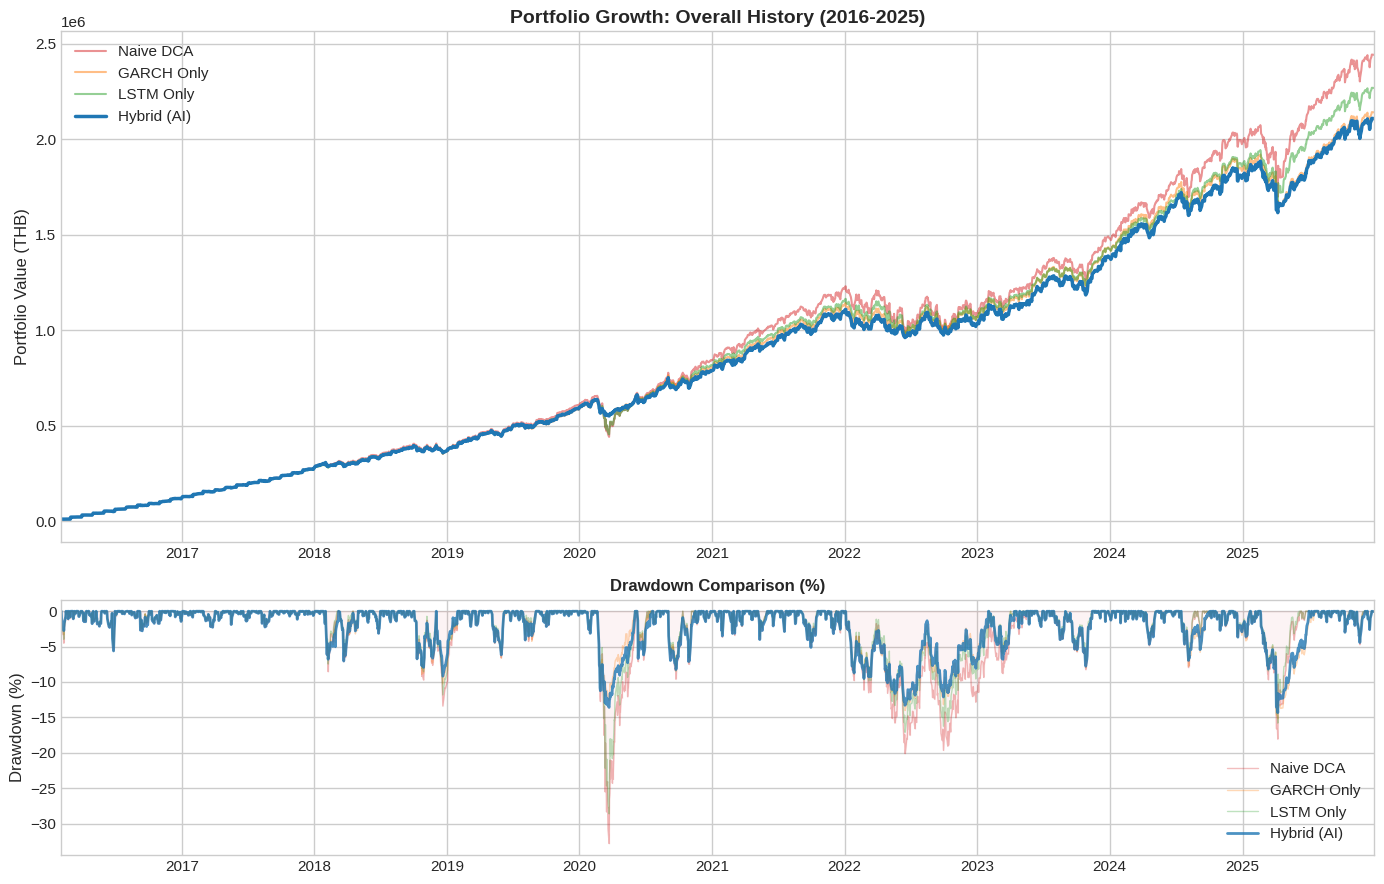

In [10]:
# =========================================================================
# 7.1 ภาพรวมมหากาพย์การลงทุน 10 ปี (2016-2025)
# =========================================================================
print("="*75)
print("📊 7.1 ตารางสรุปผลการดำเนินงานภาพรวมตลอด 10 ปี (Overall Performance)")
print("="*75)

summary_10years = []
for s, l in zip(strategies, labels):
    ret, mdd, sharpe = calculate_dca_metrics(portfolio_df, s, s.replace('Value', 'Drawdown'))
    summary_10years.append([l, f"{ret:.2f}%", f"{mdd:.2f}%", f"{sharpe:.2f}"])

print(pd.DataFrame(summary_10years, columns=['Strategy', 'Total Return', 'Max Drawdown', 'Sharpe Ratio']).to_string(index=False))
print("-" * 75)
plot_period_charts(portfolio_df, "Overall History (2016-2025)")

🚨 7.2 ตารางสรุปผลการดำเนินงานช่วงวิกฤต COVID-19 Crash (ปี 2020)
   Strategy Return (2020) Max Drawdown Sharpe Ratio
  Naive DCA        36.51%      -32.82%         1.03
 GARCH Only        35.12%      -12.60%         1.82
  LSTM Only        35.81%      -28.63%         1.11
Hybrid (AI)        31.24%      -13.59%         1.60
---------------------------------------------------------------------------


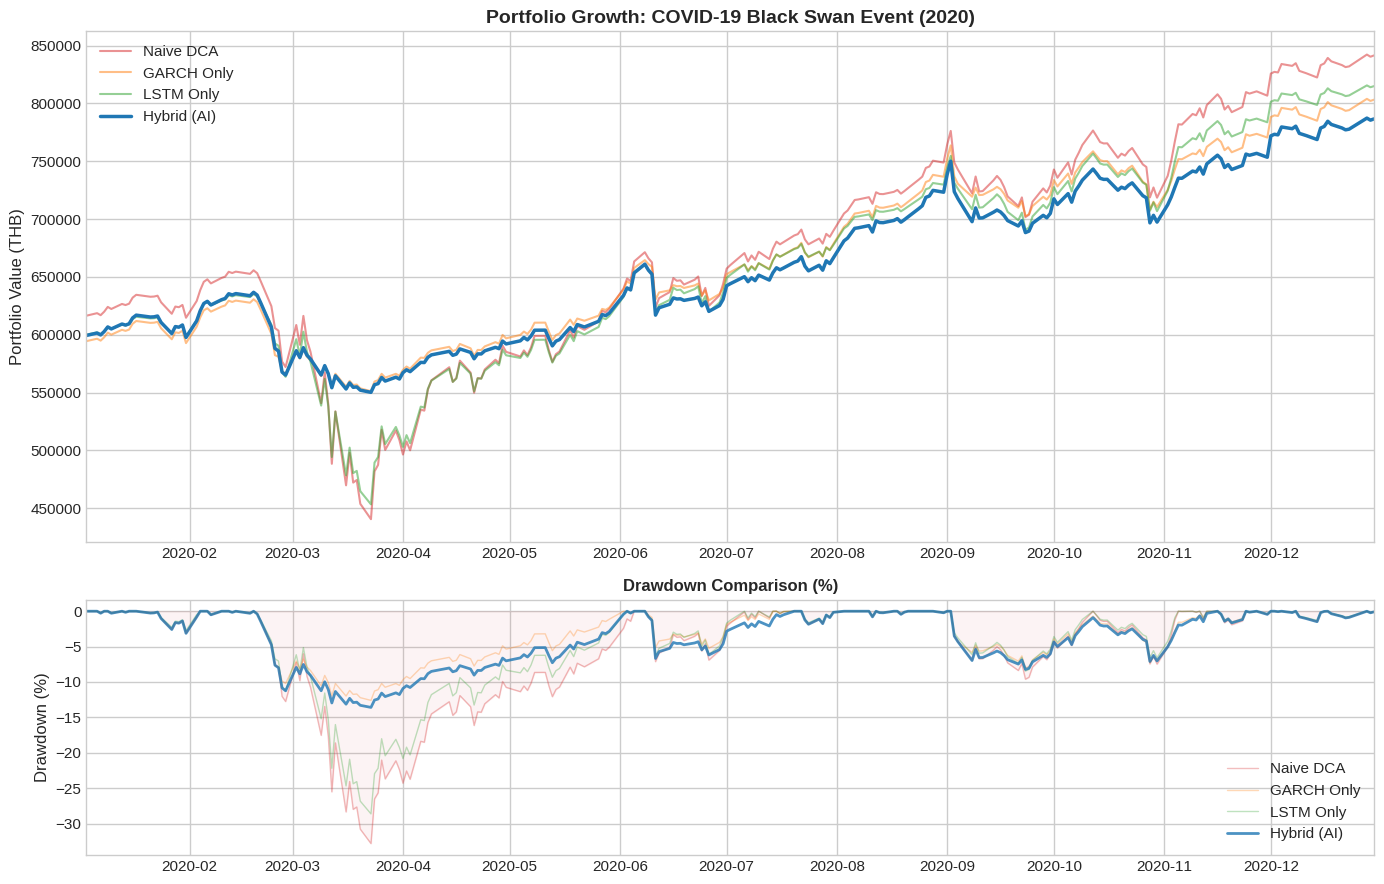

In [11]:
# =========================================================================
# 7.2 เจาะลึกวิกฤต COVID-19 (ปี 2020)
# =========================================================================
df_2020 = portfolio_df.loc['2020-01-01':'2020-12-31'].copy()
print("="*75)
print("🚨 7.2 ตารางสรุปผลการดำเนินงานช่วงวิกฤต COVID-19 Crash (ปี 2020)")
print("="*75)

summary_2020 = []
for s, l in zip(strategies, labels):
    ret, mdd, sharpe = calculate_period_metrics(df_2020, s, s.replace('Value', 'Drawdown'))
    summary_2020.append([l, f"{ret:.2f}%", f"{mdd:.2f}%", f"{sharpe:.2f}"])

print(pd.DataFrame(summary_2020, columns=['Strategy', 'Return (2020)', 'Max Drawdown', 'Sharpe Ratio']).to_string(index=False))
print("-" * 75)
plot_period_charts(df_2020, "COVID-19 Black Swan Event (2020)")

🚨 7.3 ตารางสรุปผลการดำเนินงานช่วงวิกฤต Inflation & Rate Hike (ปี 2022)
   Strategy Return (2022) Max Drawdown Sharpe Ratio
  Naive DCA       -11.55%      -20.10%        -0.46
 GARCH Only        -6.77%      -14.03%        -0.46
  LSTM Only        -8.39%      -17.10%        -0.39
Hybrid (AI)        -7.09%      -13.28%        -0.52
---------------------------------------------------------------------------


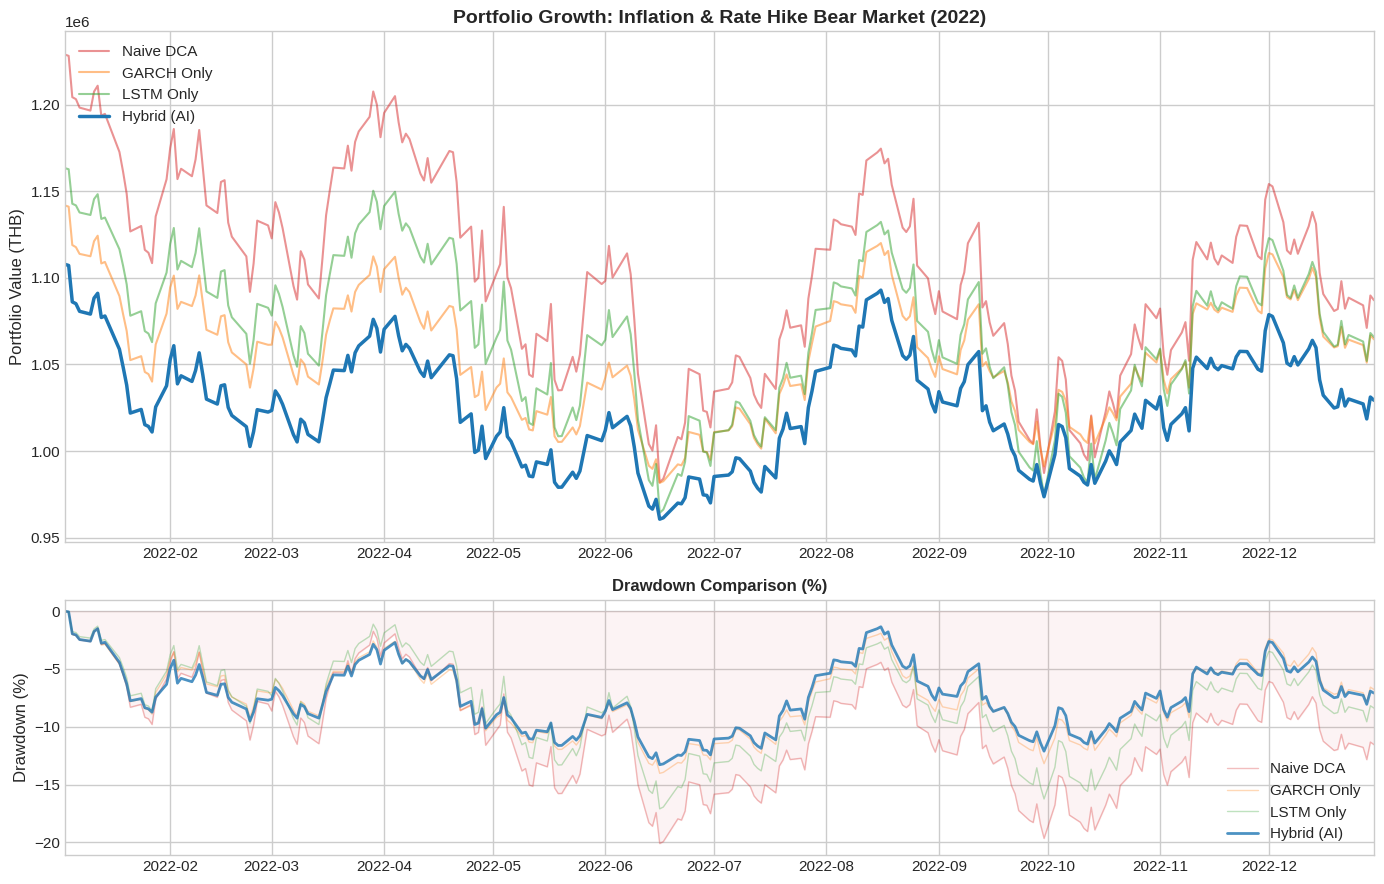

In [12]:
# =========================================================================
# 7.3 เจาะลึกวิกฤตเงินเฟ้อ (ปี 2022)
# =========================================================================
df_2022 = portfolio_df.loc['2022-01-01':'2022-12-31'].copy()
print("="*75)
print("🚨 7.3 ตารางสรุปผลการดำเนินงานช่วงวิกฤต Inflation & Rate Hike (ปี 2022)")
print("="*75)

summary_2022 = []
for s, l in zip(strategies, labels):
    ret, mdd, sharpe = calculate_period_metrics(df_2022, s, s.replace('Value', 'Drawdown'))
    summary_2022.append([l, f"{ret:.2f}%", f"{mdd:.2f}%", f"{sharpe:.2f}"])

print(pd.DataFrame(summary_2022, columns=['Strategy', 'Return (2022)', 'Max Drawdown', 'Sharpe Ratio']).to_string(index=False))
print("-" * 75)
plot_period_charts(df_2022, "Inflation & Rate Hike Bear Market (2022)")

📊 7.4 ตารางสรุปผลการดำเนินงานข้ามงวดอนาคต Out-of-Sample (2023-2025)
   Strategy Return (OOS) Max Drawdown Sharpe Ratio
  Naive DCA      123.38%      -18.06%         1.77
 GARCH Only       99.74%      -15.20%         1.76
  LSTM Only      111.48%      -15.81%         1.86
Hybrid (AI)      103.32%      -14.32%         1.86
---------------------------------------------------------------------------


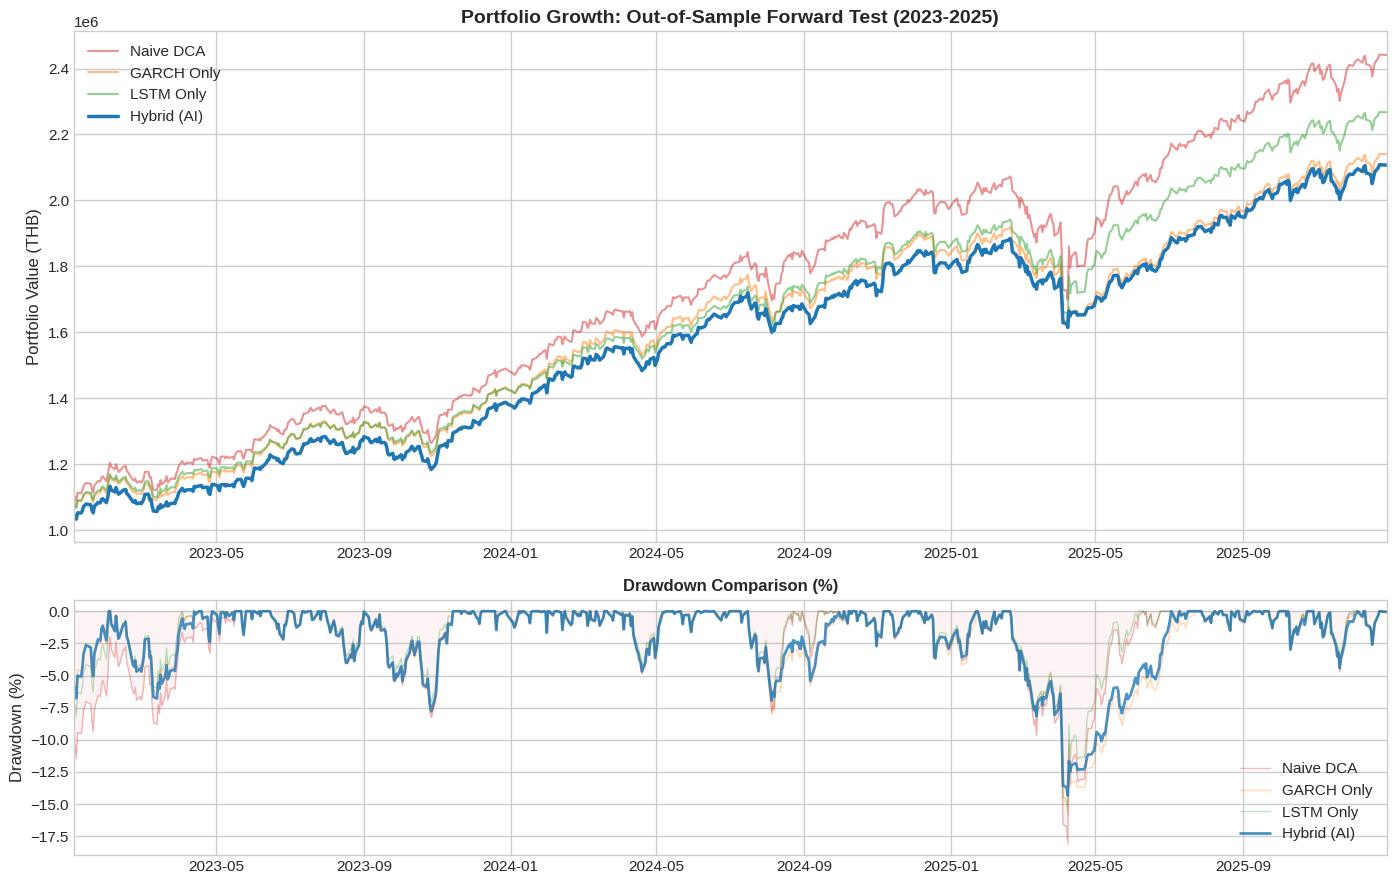

In [13]:
# =========================================================================
# 7.4 การทดสอบเดินหน้าข้ามมิติเวลา (Out-of-Sample: 2023-2025)
# =========================================================================
df_oos = portfolio_df.loc['2023-01-01':].copy()

print("="*75)
print("📊 7.4 ตารางสรุปผลการดำเนินงานข้ามงวดอนาคต Out-of-Sample (2023-2025)")
print("="*75)

summary_oos = []
for s, l in zip(strategies, labels):
    # ✅ เปลี่ยนมาใช้ฟังก์ชัน calculate_period_metrics แทน
    # เพื่อวัดผลตอบแทนเฉพาะช่วงเวลา OOS นี้เท่านั้น (ไม่เอาเงินต้น 10 ปีมาเกี่ยว)
    ret, mdd, sharpe = calculate_period_metrics(df_oos, s, s.replace('Value', 'Drawdown'))
    summary_oos.append([l, f"{ret:.2f}%", f"{mdd:.2f}%", f"{sharpe:.2f}"])

print(pd.DataFrame(summary_oos, columns=['Strategy', 'Return (OOS)', 'Max Drawdown', 'Sharpe Ratio']).to_string(index=False))
print("-" * 75)

# แสดงกราฟต่อเนื่องทันที (ใช้ฟังก์ชันเดิมได้เลย)
plot_period_charts(df_oos, "Out-of-Sample Forward Test (2023-2025)")

📌 1. กราฟสำหรับสไลด์: Stress Test ช่วงวิกฤต Covid-19


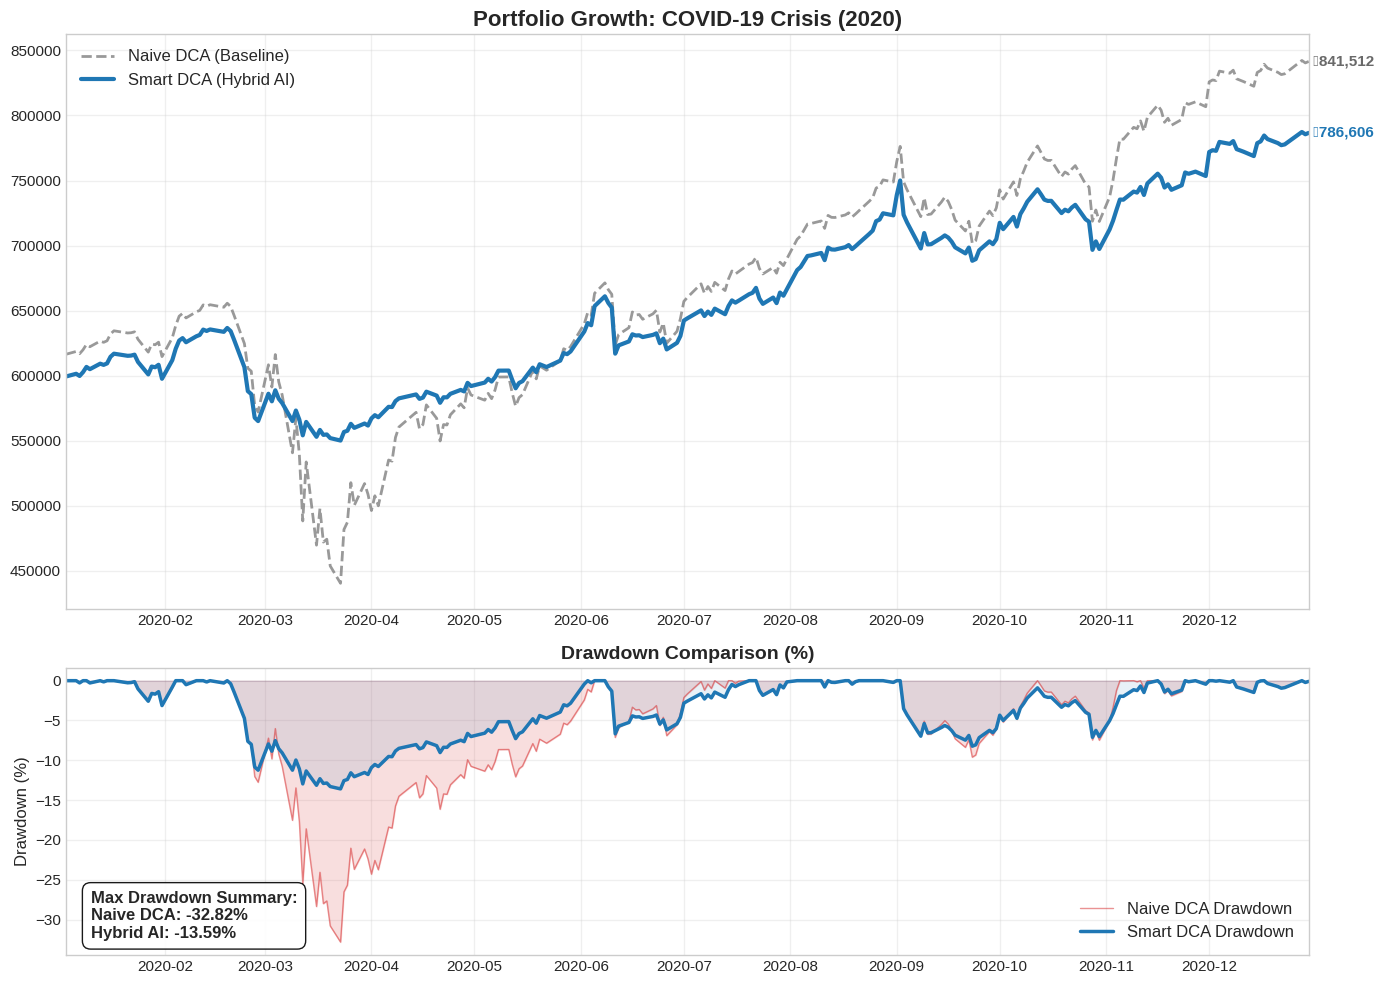


📌 2. กราฟสำหรับสไลด์: Stress Test ช่วงวิกฤตเงินเฟ้อ 2022


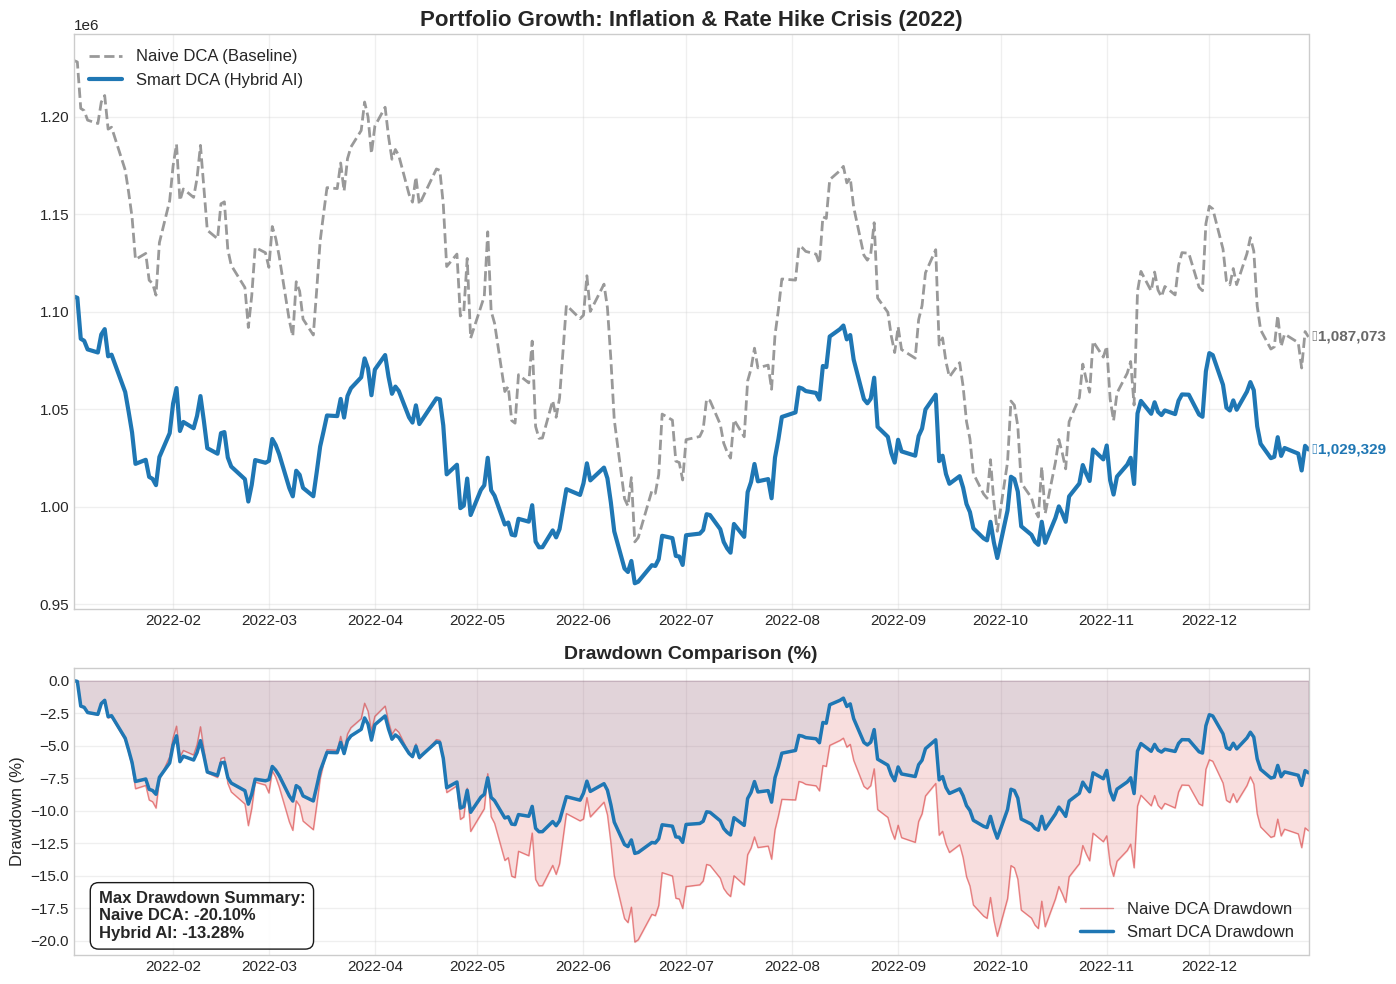


📌 3. กราฟสำหรับสไลด์: Out-of-Sample Test (2023-2025)


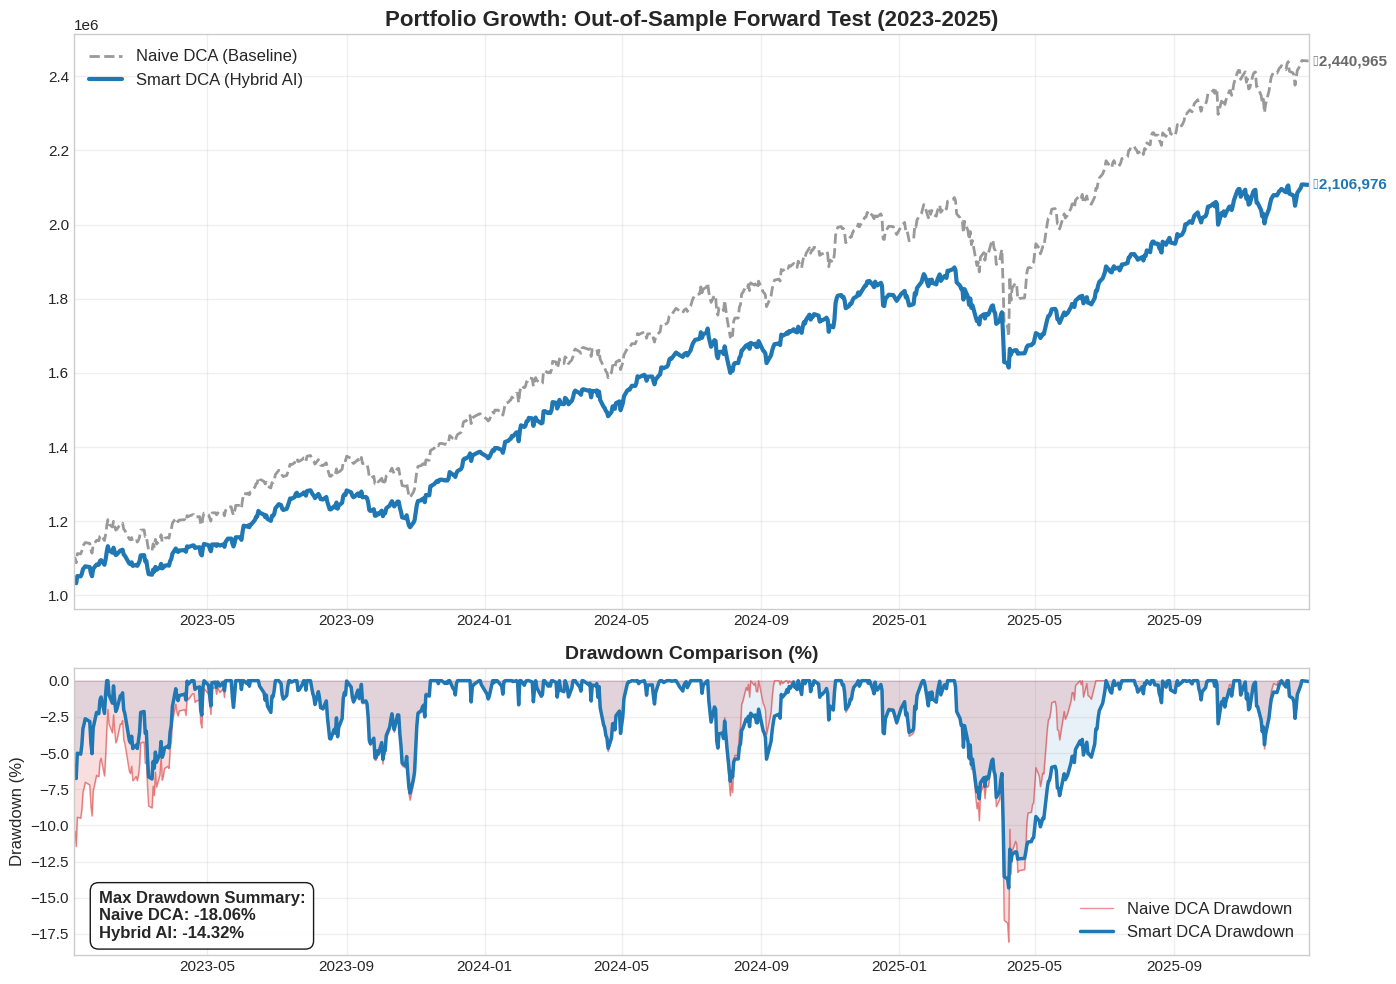

In [14]:
# =========================================================================
# Extra Cell: กราฟ 2 เส้นสำหรับ Presentation (แบบ Clean & Professional)
# แก้ไข: ย้ายตัวเลข Max Drawdown ไปไว้ใน Text Box สรุป เพื่อไม่ให้ทับเส้นกราฟ
# =========================================================================
import matplotlib.pyplot as plt
import pandas as pd

def plot_presentation_charts(df, title_name):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

    # --- กราฟบน (Growth) ---
    ax1.plot(df.index, df['Naive_Value'], label='Naive DCA (Baseline)', color='gray', linestyle='--', linewidth=2, alpha=0.8)
    ax1.plot(df.index, df['Hybrid_Value'], label='Smart DCA (Hybrid AI)', color='#1f77b4', linewidth=3)

    last_date = df.index[-1]
    naive_end_val = df['Naive_Value'].iloc[-1]
    hybrid_end_val = df['Hybrid_Value'].iloc[-1]

    # ปรับตำแหน่งตัวเลขให้ห่างจากเส้นเล็กน้อย
    ax1.text(last_date, naive_end_val, f' ฿{naive_end_val:,.0f}', color='dimgray', fontsize=11, fontweight='bold', va='center')
    ax1.text(last_date, hybrid_end_val, f' ฿{hybrid_end_val:,.0f}', color='#1f77b4', fontsize=11, fontweight='bold', va='center')

    ax1.set_title(f'Portfolio Growth: {title_name}', fontsize=16, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # --- กราฟล่าง (Drawdown) ---
    ax2.fill_between(df.index, df['Naive_Drawdown'] * 100, 0, color='#d62728', alpha=0.15)
    ax2.plot(df.index, df['Naive_Drawdown'] * 100, label='Naive DCA Drawdown', color='#d62728', linewidth=1, alpha=0.5)

    ax2.fill_between(df.index, df['Hybrid_Drawdown'] * 100, 0, color='#1f77b4', alpha=0.1)
    ax2.plot(df.index, df['Hybrid_Drawdown'] * 100, label='Smart DCA Drawdown', color='#1f77b4', linewidth=2.5)

    # คำนวณค่า Max Drawdown
    naive_min_val = df['Naive_Drawdown'].min() * 100
    hybrid_min_val = df['Hybrid_Drawdown'].min() * 100

    # 🎯 [ปรับปรุง] สร้างกล่องข้อความ (Text Box) สรุปตัวเลขไว้ที่มุมซ้ายล่าง
    textstr = f"Max Drawdown Summary:\nNaive DCA: {naive_min_val:.2f}%\nHybrid AI: {hybrid_min_val:.2f}%"
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black')

    # ปรับพิกัดจากมุมซ้ายบน (0.02, 0.95) มาเป็นมุมซ้ายล่าง (0.02, 0.05)
    ax2.text(0.02, 0.05, textstr, transform=ax2.transAxes, fontsize=12,
             verticalalignment='bottom', bbox=props, fontweight='bold')

    ax2.set_title('Drawdown Comparison (%)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Drawdown (%)', fontsize=12)

    # ย้าย Legend ไปมุมขวาบน หรือมุมขวาล่างตามที่เหมาะสม เพื่อไม่ให้ทับกล่องซ้ายล่าง
    ax2.legend(loc='lower right', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax1.set_xlim(df.index.min(), df.index.max())
    ax2.set_xlim(df.index.min(), df.index.max())
    plt.tight_layout()
    plt.show()

# =========================================================================
# รันเพื่อวาดกราฟ 3 ช่วงเวลาสำคัญ
# =========================================================================
print("📌 1. กราฟสำหรับสไลด์: Stress Test ช่วงวิกฤต Covid-19")
df_covid = portfolio_df.loc['2020-01-01':'2020-12-31']
plot_presentation_charts(df_covid, "COVID-19 Crisis (2020)")

print("\n📌 2. กราฟสำหรับสไลด์: Stress Test ช่วงวิกฤตเงินเฟ้อ 2022")
df_inflation = portfolio_df.loc['2022-01-01':'2022-12-31']
plot_presentation_charts(df_inflation, "Inflation & Rate Hike Crisis (2022)")

print("\n📌 3. กราฟสำหรับสไลด์: Out-of-Sample Test (2023-2025)")
df_oos = portfolio_df.loc['2023-01-01':]
plot_presentation_charts(df_oos, "Out-of-Sample Forward Test (2023-2025)")

In [15]:
# =========================================================================
# Extra Cell 2: ตารางสรุปสถิติแบบเจาะลึก (Comprehensive Summary Tables)
# รวมครบทั้ง 4 กลยุทธ์ (Naive, GARCH, LSTM, Hybrid) พร้อม Sharpe Ratio
# =========================================================================
import pandas as pd
import numpy as np

# ตั้งค่าตัวแปรให้ครบทั้ง 4 โมเดล
strategies = ['Naive_Value', 'GARCH_Value', 'Base_Value', 'Hybrid_Value']
labels = ['Naive DCA', 'GARCH Only', 'LSTM Only', 'Hybrid (AI)']

def generate_summary_table(df, title, is_dca=False, monthly_dca=10000):
    results = []
    for s, l in zip(strategies, labels):
        dd_col = s.replace('Value', 'Drawdown')

        # 1. คำนวณ Max Drawdown
        max_dd = df[dd_col].min() * 100

        # 2. คำนวณ Return (แบ่งตรรกะระยะยาว กับ ระยะสั้น)
        if is_dca:
            # ใช้ตรรกะผลตอบแทนจากเงินต้นสะสม (สำหรับ 10 ปี และ OOS)
            total_months = df.groupby([df.index.year, df.index.month]).ngroups
            total_invested = total_months * monthly_dca
            end_val = df[s].iloc[-1]
            ret = ((end_val - total_invested) / total_invested) * 100
        else:
            # ใช้ตรรกะ Point-to-Point (สำหรับวิกฤตสั้นๆ 1 ปี)
            start_val = df[s].iloc[0]
            end_val = df[s].iloc[-1]
            ret = ((end_val - start_val) / start_val) * 100

        # 3. คำนวณ Sharpe Ratio
        if is_dca:
            is_first_day = df.index.month != pd.Series(df.index.month).shift(1).values
            is_first_day[0] = True
            prev_val = df[s].shift(1)
            adj_val = df[s] - np.where(is_first_day, monthly_dca, 0)
            daily_ret = (adj_val - prev_val) / prev_val
            daily_ret = daily_ret.dropna()
        else:
            daily_ret = df[s].pct_change().dropna()

        excess_ret = daily_ret - (0.02 / 252) # หัก Risk-free rate 2%
        sharpe = (excess_ret.mean() / excess_ret.std()) * np.sqrt(252) if excess_ret.std() > 0 else 0

        results.append([l, f"{ret:.2f}%", f"{max_dd:.2f}%", f"{sharpe:.2f}"])

    # สร้างและปรินต์ DataFrame
    df_res = pd.DataFrame(results, columns=['Strategy', 'Return', 'Max Drawdown', 'Sharpe Ratio'])
    print("="*65)
    print(f"📊 {title}")
    print("="*65)
    print(df_res.to_string(index=False))
    print("-" * 65 + "\n")

# =========================================================================
# สั่งปรินต์ตารางทั้ง 4 ช่วงเวลา
# =========================================================================
# 1. ตารางภาพรวม 10 ปี
generate_summary_table(portfolio_df, "1. Overall Performance (10 Years: 2016-2025)", is_dca=True)

# 2. ตารางช่วงวิกฤตโควิด (2020)
df_covid = portfolio_df.loc['2020-01-01':'2020-12-31']
generate_summary_table(df_covid, "2. Stress Test: COVID-19 Crisis (2020)", is_dca=False)

# 3. ตารางช่วงวิกฤตเงินเฟ้อ (2022)
df_inflation = portfolio_df.loc['2022-01-01':'2022-12-31']
generate_summary_table(df_inflation, "3. Stress Test: Inflation & Rate Hike (2022)", is_dca=False)

# 4. ตารางใช้งานจริง (2023-2025)
df_oos = portfolio_df.loc['2023-01-01':]
generate_summary_table(df_oos, "4. Out-of-Sample: Forward Test (2023-2025)", is_dca=False)

📊 1. Overall Performance (10 Years: 2016-2025)
   Strategy  Return Max Drawdown Sharpe Ratio
  Naive DCA 105.12%      -32.82%         0.71
 GARCH Only  79.81%      -15.20%         0.79
  LSTM Only  90.53%      -28.63%         0.71
Hybrid (AI)  77.06%      -14.32%         0.78
-----------------------------------------------------------------

📊 2. Stress Test: COVID-19 Crisis (2020)
   Strategy Return Max Drawdown Sharpe Ratio
  Naive DCA 36.51%      -32.82%         1.03
 GARCH Only 35.12%      -12.60%         1.82
  LSTM Only 35.81%      -28.63%         1.11
Hybrid (AI) 31.24%      -13.59%         1.60
-----------------------------------------------------------------

📊 3. Stress Test: Inflation & Rate Hike (2022)
   Strategy  Return Max Drawdown Sharpe Ratio
  Naive DCA -11.55%      -20.10%        -0.46
 GARCH Only  -6.77%      -14.03%        -0.46
  LSTM Only  -8.39%      -17.10%        -0.39
Hybrid (AI)  -7.09%      -13.28%        -0.52
----------------------------------------------